Loaded subject 6269757
N trials = 1192

lambda_A = 0.142019
lambda_B = 0.143629

FITTED POINT
Fitted loss = 0.055159
Fitted parameters:
  sigma_noise         : 0.118160
  A_repulsion         : 0.264088
  gamma               : 0.842005
  sigma_update        : 0.486071
  eta_learning        : 0.336001
  sigma_boundary      : 4.726866
  alpha               : 0.693673

BETTER SOLUTION FOUND
Direction: 0
Alpha: 0.0500
Loss: 0.055142
Params:
  sigma_noise         : 0.119778
  A_repulsion         : 0.268459
  gamma               : 0.845486
  sigma_update        : 0.476504
  eta_learning        : 0.345538
  sigma_boundary      : 4.774311
  alpha               : 0.687960

BETTER SOLUTION FOUND
Direction: 1
Alpha: 0.0500
Loss: 0.055142
Params:
  sigma_noise         : 0.119890
  A_repulsion         : 0.265322
  gamma               : 0.843975
  sigma_update        : 0.486204
  eta_learning        : 0.339663
  sigma_boundary      : 4.677097
  alpha               : 0.692571

BETTER SOLUTION FOUND
Di

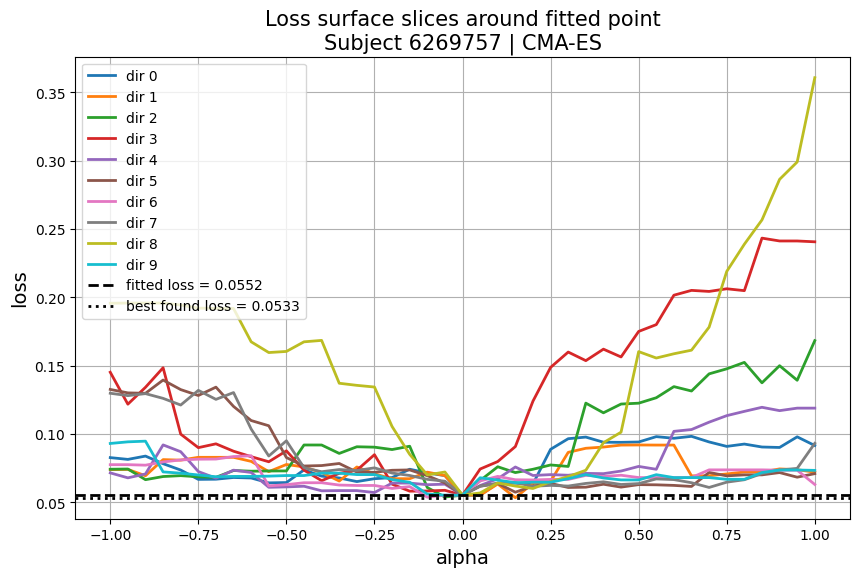

Saved zoomed figure to:
losses\6269757_CMA-ES_loss_zoomed.pdf


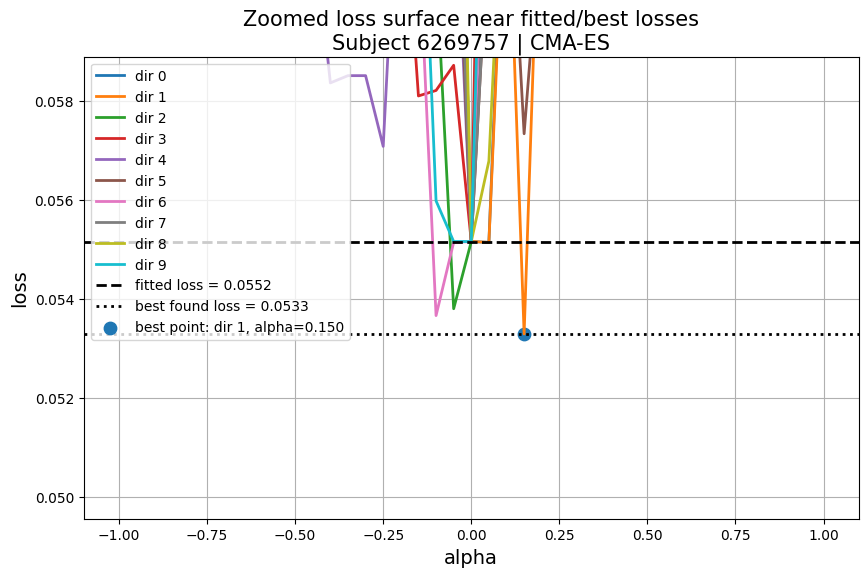


FINAL REPORT
Fitted loss: 0.055159
Fitted parameters:
  sigma_noise         : 0.118160
  A_repulsion         : 0.264088
  gamma               : 0.842005
  sigma_update        : 0.486071
  eta_learning        : 0.336001
  sigma_boundary      : 4.726866
  alpha               : 0.693673

Best found loss: 0.053293
Best found direction: 1
Best found alpha: 0.1500
Euclidean distance from fitted parameters: 0.150000
Best found parameters:
  sigma_noise         : 0.123349
  A_repulsion         : 0.267788
  gamma               : 0.847915
  sigma_update        : 0.486469
  eta_learning        : 0.346986
  sigma_boundary      : 4.577558
  alpha               : 0.690367


In [4]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import uniform

from Hybrid import Hybrid_model
from BE import Noise_generator, Delta_repulsion, Delta_learning
from Fitter import post_correct_update_matrix, matrix_error, total_psychometric


def run_loss_surface(
    subject,
    opt_method,
    seed=1,
    csv_path=r"D:\sc_modelling-amir-2025\Human_Data_switching.csv",
    base_results_dir=r"D:\sc_modelling-amir-2025\Hybrid_new3_fit\Human\results",
    save_dir="losses",
    fit_with="conditional",
    mode_pre="simulated",
    n_directions=10,
    alphas=np.linspace(-1.0, 1.0, 41),
    dpi=300,
):
    subject = str(subject)
    opt_method = str(opt_method)

    result_path = (
        rf"{base_results_dir}\{opt_method}\{subject}"
        rf"\results_pid_{subject}_seed_{seed}_{opt_method}.pkl"
    )

    os.makedirs(save_dir, exist_ok=True)

    df = pd.read_csv(csv_path)

    id_col = "Participant Private ID"
    df[id_col] = pd.to_numeric(df[id_col], errors="coerce").astype("Int64").astype(str)
    subject = str(int(float(subject)))

    pid_df = df[df[id_col] == subject].reset_index(drop=True)

    if len(pid_df) == 0:
        print("Subject not found.")
        print("Example subject IDs in file:")
        print(df[id_col].dropna().unique()[:30])
        raise ValueError(f"No rows found for subject {subject}")

    pid_df["No_response"] = False
    pid_df["is_not_start_of_block"] = pid_df["block"].eq(pid_df["block"].shift())

    print(f"Loaded subject {subject}")
    print(f"N trials = {len(pid_df)}")

    with open(result_path, "rb") as f:
        results = pickle.load(f)

    best_params = results["best_params"]

    s = pid_df["stim_relative"].to_numpy()
    chooseB = pid_df["choice"].to_numpy()
    no_response = pid_df["No_response"].to_numpy()

    _, fit_params = total_psychometric(s, chooseB, no_response)

    lambda_A = np.clip(fit_params[2], 0.0, 0.5)
    lambda_B = np.clip(fit_params[3], 0.0, 0.5)

    print(f"\nlambda_A = {lambda_A:.6f}")
    print(f"lambda_B = {lambda_B:.6f}")

    param_names = [
        "sigma_noise",
        "A_repulsion",
        "gamma",
        "sigma_update",
        "eta_learning",
        "sigma_boundary",
        "alpha",
    ]

    bounds = {
        "sigma_noise":    (0.01, 0.45),
        "A_repulsion":    (0.0, 0.5),
        "gamma":          (0.01, 1.0),
        "sigma_update":   (0.01, 0.7),
        "eta_learning":   (0.01, 1.0),
        "sigma_boundary": (0.01, 10.0),
        "alpha":          (0.0, 1.0),
    }

    theta_best = np.array([best_params[k] for k in param_names], dtype=float)

    def vector_to_params(theta):
        return {k: float(v) for k, v in zip(param_names, theta)}

    def clip_to_bounds(theta):
        theta = np.asarray(theta, dtype=float).copy()
        for i, name in enumerate(param_names):
            low, high = bounds[name]
            theta[i] = np.clip(theta[i], low, high)
        return theta

    def evaluate_loss(theta):
        theta = clip_to_bounds(theta)
        params = vector_to_params(theta)

        s = pid_df["stim_relative"].to_numpy()
        chooseB = pid_df["choice"].to_numpy()
        rewards = pid_df["correct"].to_numpy()
        no_response = pid_df["No_response"].to_numpy()
        not_blockstart = pid_df["is_not_start_of_block"].to_numpy()

        categories = np.where(s > 0, 1, 0)

        data_mat, cond_mat = post_correct_update_matrix(
            s,
            chooseB,
            rewards,
            no_response,
            not_blockstart
        )

        target_matrix = cond_mat[::-1] if fit_with == "conditional" else data_mat[::-1]

        sigma_noise = params["sigma_noise"]
        A_repulsion = params["A_repulsion"]

        max_range = 1 + 6 * sigma_noise + 2 * A_repulsion * (1 + 6 * sigma_noise)
        min_range = -1 - 6 * sigma_noise - 2 * A_repulsion * (1 + 6 * sigma_noise)

        num_points = max(10, round((max_range - min_range) * 1000))
        x_grid = np.linspace(min_range, max_range, num_points)

        y_BE_initial = uniform.pdf(
            x_grid,
            loc=min_range,
            scale=max_range - min_range
        )

        s_tilde = s + Noise_generator(len(s), seed, sigma_noise)
        s_hat = Delta_repulsion(A_repulsion, s_tilde)

        Final_up, Final_cond, SC_up, SC_cond, BE_up, BE_cond = Hybrid_model(
            func=post_correct_update_matrix,
            x=x_grid,
            s=s,
            s_hat=s_hat,
            categories=categories,
            y_BE=y_BE_initial.copy(),
            Delta_learning=Delta_learning,
            lambda_A=lambda_A,
            lambda_B=lambda_B,
            no_response=no_response,
            Not_Blockstart=not_blockstart,
            seed=seed,
            mode=mode_pre,
            **params
        )

        sim_matrix = Final_cond if fit_with == "conditional" else Final_up
        return matrix_error(sim_matrix, target_matrix)

    def random_direction(rng):
        v = rng.normal(size=len(theta_best))

        ranges = np.array([
            bounds[k][1] - bounds[k][0]
            for k in param_names
        ])

        v = v * ranges
        v = v / np.linalg.norm(v)
        return v

    theta_best = clip_to_bounds(theta_best)
    fitted_loss = evaluate_loss(theta_best)
    fitted_params = vector_to_params(theta_best)

    print("\n====================================")
    print("FITTED POINT")
    print("====================================")
    print(f"Fitted loss = {fitted_loss:.6f}")
    print("Fitted parameters:")
    for k, v in fitted_params.items():
        print(f"  {k:20s}: {v:.6f}")

    rng = np.random.default_rng(seed)

    all_results = []
    better_solutions = []

    best_found_loss = fitted_loss
    best_found_theta = theta_best.copy()
    best_found_params = fitted_params.copy()
    best_found_direction = None
    best_found_alpha = 0.0

    for d in range(n_directions):
        v = random_direction(rng)
        losses = []
        theta_values = []

        for alpha in alphas:
            theta_raw = theta_best + alpha * v
            theta = clip_to_bounds(theta_raw)

            loss = evaluate_loss(theta)

            losses.append(loss)
            theta_values.append(theta)

            if loss < fitted_loss:
                params = vector_to_params(theta)

                better_solutions.append({
                    "direction": d,
                    "alpha": alpha,
                    "loss": loss,
                    "theta": theta.copy(),
                    "params": params,
                })

                print("\nBETTER SOLUTION FOUND")
                print(f"Direction: {d}")
                print(f"Alpha: {alpha:.4f}")
                print(f"Loss: {loss:.6f}")
                print("Params:")
                for k, v_param in params.items():
                    print(f"  {k:20s}: {v_param:.6f}")

            if loss < best_found_loss:
                best_found_loss = loss
                best_found_theta = theta.copy()
                best_found_params = vector_to_params(theta)
                best_found_direction = d
                best_found_alpha = alpha

        all_results.append({
            "direction": d,
            "v": v,
            "alphas": alphas.copy(),
            "losses": np.array(losses),
            "theta_values": np.array(theta_values),
        })

    distance_best_to_fitted = np.linalg.norm(best_found_theta - theta_best)

    # =========================================================================
    # MAIN PLOT
    # =========================================================================

    plt.figure(figsize=(10, 6))

    for result in all_results:
        plt.plot(
            result["alphas"],
            result["losses"],
            linewidth=2,
            label=f"dir {result['direction']}"
        )

    plt.axhline(
        fitted_loss,
        linestyle="--",
        color="black",
        linewidth=2,
        label=f"fitted loss = {fitted_loss:.4f}"
    )

    plt.axhline(
        best_found_loss,
        linestyle=":",
        color="black",
        linewidth=2,
        label=f"best found loss = {best_found_loss:.4f}"
    )

    plt.xlabel("alpha", fontsize=14)
    plt.ylabel("loss", fontsize=14)

    plt.title(
        f"Loss surface slices around fitted point\n"
        f"Subject {subject} | {opt_method}",
        fontsize=15
    )

    plt.legend(loc="upper left")
    plt.grid(True)

    pdf_name = f"{subject}_{opt_method}_loss.pdf"
    pdf_path = os.path.join(save_dir, pdf_name)

    plt.savefig(pdf_path, format="pdf", dpi=dpi, bbox_inches="tight")
    print(f"\nSaved main figure to:\n{pdf_path}")

    plt.show()

    # =========================================================================
    # ZOOMED-IN PLOT AROUND FITTED AND BEST FOUND LOSSES
    # =========================================================================

    all_loss_values = np.concatenate([r["losses"] for r in all_results])

    y_min = min(fitted_loss, best_found_loss, np.nanmin(all_loss_values))
    y_max_reference = max(fitted_loss, best_found_loss)

    vertical_gap = abs(fitted_loss - best_found_loss)

    if vertical_gap == 0:
        y_margin = 0.05 * abs(fitted_loss) if fitted_loss != 0 else 0.01
    else:
        y_margin = 2.0 * vertical_gap

    zoom_y_low = y_min - y_margin
    zoom_y_high = y_max_reference + y_margin

    plt.figure(figsize=(10, 6))

    for result in all_results:
        plt.plot(
            result["alphas"],
            result["losses"],
            linewidth=2,
            label=f"dir {result['direction']}"
        )

    plt.axhline(
        fitted_loss,
        linestyle="--",
        color="black",
        linewidth=2,
        label=f"fitted loss = {fitted_loss:.4f}"
    )

    plt.axhline(
        best_found_loss,
        linestyle=":",
        color="black",
        linewidth=2,
        label=f"best found loss = {best_found_loss:.4f}"
    )

    if best_found_direction is not None:
        plt.scatter(
            [best_found_alpha],
            [best_found_loss],
            s=80,
            marker="o",
            label=f"best point: dir {best_found_direction}, alpha={best_found_alpha:.3f}"
        )

    plt.ylim(zoom_y_low, zoom_y_high)

    plt.xlabel("alpha", fontsize=14)
    plt.ylabel("loss", fontsize=14)

    plt.title(
        f"Zoomed loss surface near fitted/best losses\n"
        f"Subject {subject} | {opt_method}",
        fontsize=15
    )

    plt.legend(loc="upper left")
    plt.grid(True)

    zoom_pdf_name = f"{subject}_{opt_method}_loss_zoomed.pdf"
    zoom_pdf_path = os.path.join(save_dir, zoom_pdf_name)

    plt.savefig(zoom_pdf_path, format="pdf", dpi=dpi, bbox_inches="tight")
    print(f"Saved zoomed figure to:\n{zoom_pdf_path}")

    plt.show()

    better_solutions = sorted(better_solutions, key=lambda x: x["loss"])

    print("\n====================================")
    print("FINAL REPORT")
    print("====================================")

    print(f"Fitted loss: {fitted_loss:.6f}")
    print("Fitted parameters:")
    for k, v in fitted_params.items():
        print(f"  {k:20s}: {v:.6f}")

    print(f"\nBest found loss: {best_found_loss:.6f}")
    print(f"Best found direction: {best_found_direction}")
    print(f"Best found alpha: {best_found_alpha:.4f}")
    print(f"Euclidean distance from fitted parameters: {distance_best_to_fitted:.6f}")
    print("Best found parameters:")
    for k, v in best_found_params.items():
        print(f"  {k:20s}: {v:.6f}")

    return {
        "subject": subject,
        "opt_method": opt_method,
        "fitted_loss": fitted_loss,
        "fitted_params": fitted_params,
        "best_found_loss": best_found_loss,
        "best_found_params": best_found_params,
        "best_found_direction": best_found_direction,
        "best_found_alpha": best_found_alpha,
        "distance_best_to_fitted": distance_best_to_fitted,
        "all_results": all_results,
        "better_solutions": better_solutions,
        "pdf_path": pdf_path,
        "zoom_pdf_path": zoom_pdf_path,
    }


results = run_loss_surface(
    subject="6269757",
    opt_method="CMA-ES",
)

In [5]:
results

{'subject': '6269757',
 'opt_method': 'CMA-ES',
 'fitted_loss': np.float64(0.05515922432036627),
 'fitted_params': {'sigma_noise': 0.1181600274991355,
  'A_repulsion': 0.2640884217428468,
  'gamma': 0.8420053835181739,
  'sigma_update': 0.4860711860944819,
  'eta_learning': 0.33600138997187307,
  'sigma_boundary': 4.726865669841928,
  'alpha': 0.6936729778887482},
 'best_found_loss': np.float64(0.05329268406536383),
 'best_found_params': {'sigma_noise': 0.12334907347711527,
  'A_repulsion': 0.26778776153213113,
  'gamma': 0.8479148549920785,
  'sigma_update': 0.48646918130869493,
  'eta_learning': 0.3469855037149499,
  'sigma_boundary': 4.5775581774704985,
  'alpha': 0.6903668622366276},
 'best_found_direction': 1,
 'best_found_alpha': np.float64(0.15000000000000013),
 'distance_best_to_fitted': np.float64(0.1500000000000002),
 'all_results': [{'direction': 0,
   'v': array([ 0.03235674,  0.08741747,  0.06961169, -0.19133928,  0.19072725,
           0.94890593, -0.11426012]),
   'alpha

Loaded subject 6269757
N trials = 1192

lambda_A = 0.142019
lambda_B = 0.143629

FITTED POINT
Fitted loss = 0.057932
Fitted parameters:
  sigma_noise         : 0.126412
  A_repulsion         : 0.339304
  gamma               : 0.939783
  sigma_update        : 0.272976
  eta_learning        : 0.547309
  sigma_boundary      : 9.295416
  alpha               : 0.451329

BETTER SOLUTION FOUND
Direction: 0
Alpha: -0.5500
Loss: 0.057572
Params:
  sigma_noise         : 0.108616
  A_repulsion         : 0.291224
  gamma               : 0.901497
  sigma_update        : 0.378213
  eta_learning        : 0.442409
  sigma_boundary      : 8.773518
  alpha               : 0.514172

BETTER SOLUTION FOUND
Direction: 0
Alpha: -0.4500
Loss: 0.056212
Params:
  sigma_noise         : 0.111851
  A_repulsion         : 0.299966
  gamma               : 0.908458
  sigma_update        : 0.359079
  eta_learning        : 0.461482
  sigma_boundary      : 8.868409
  alpha               : 0.502746

BETTER SOLUTION FOUND


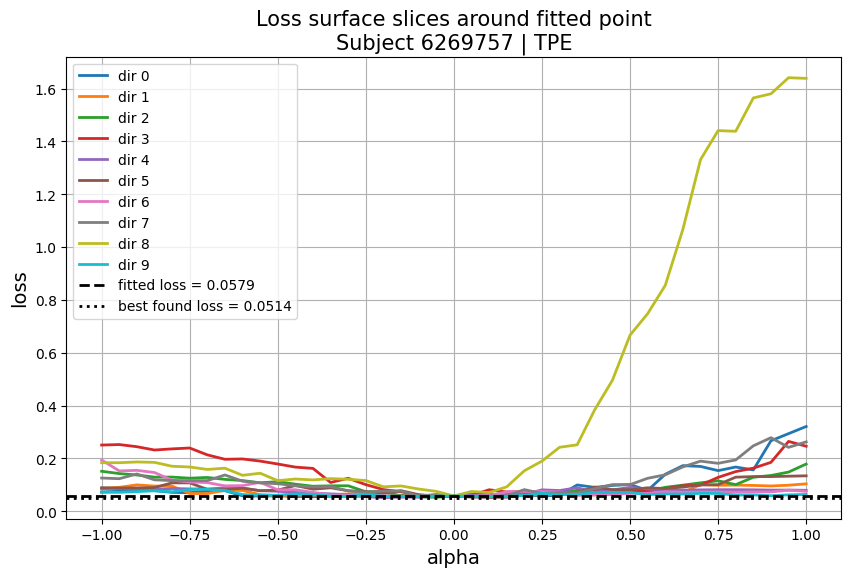

Saved zoomed figure to:
losses\6269757_TPE_loss_zoomed.pdf


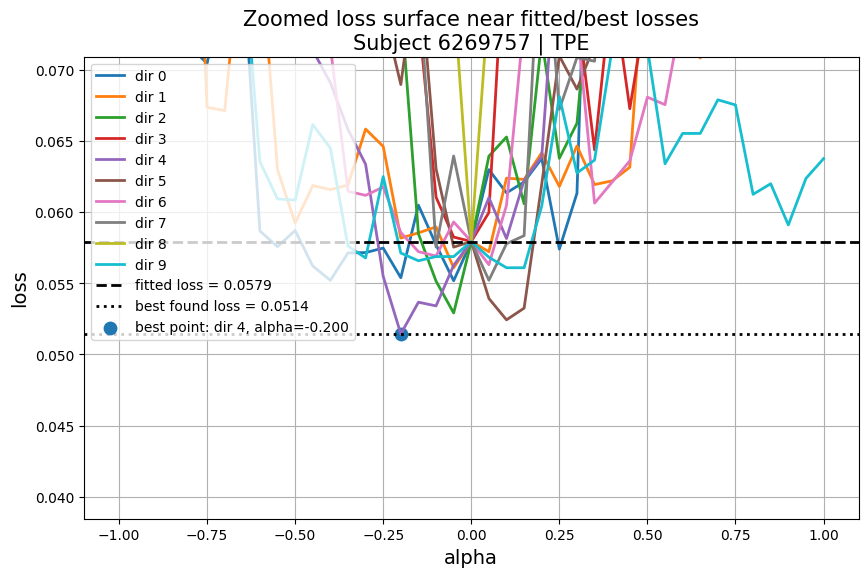


FINAL REPORT
Fitted loss: 0.057932
Fitted parameters:
  sigma_noise         : 0.126412
  A_repulsion         : 0.339304
  gamma               : 0.939783
  sigma_update        : 0.272976
  eta_learning        : 0.547309
  sigma_boundary      : 9.295416
  alpha               : 0.451329

Best found loss: 0.051438
Best found direction: 4
Best found alpha: -0.2000
Euclidean distance from fitted parameters: 0.200000
Best found parameters:
  sigma_noise         : 0.125497
  A_repulsion         : 0.338246
  gamma               : 0.919371
  sigma_update        : 0.280447
  eta_learning        : 0.550948
  sigma_boundary      : 9.096739
  alpha               : 0.445032


In [6]:
results = run_loss_surface(
    subject="6269757",
    opt_method="TPE",
)

Loaded subject 6269770
N trials = 1200

lambda_A = 0.022115
lambda_B = 0.008210

FITTED POINT
Fitted loss = 0.041005
Fitted parameters:
  sigma_noise         : 0.104845
  A_repulsion         : 0.459508
  gamma               : 0.770726
  sigma_update        : 0.398532
  eta_learning        : 0.688318
  sigma_boundary      : 0.388483
  alpha               : 0.979646

BETTER SOLUTION FOUND
Direction: 0
Alpha: 0.3000
Loss: 0.038886
Params:
  sigma_noise         : 0.114553
  A_repulsion         : 0.485733
  gamma               : 0.791609
  sigma_update        : 0.341130
  eta_learning        : 0.745536
  sigma_boundary      : 0.673154
  alpha               : 0.945368

BETTER SOLUTION FOUND
Direction: 0
Alpha: 0.4000
Loss: 0.036930
Params:
  sigma_noise         : 0.117788
  A_repulsion         : 0.494475
  gamma               : 0.798570
  sigma_update        : 0.321996
  eta_learning        : 0.764609
  sigma_boundary      : 0.768045
  alpha               : 0.933942

BETTER SOLUTION FOUND
Di

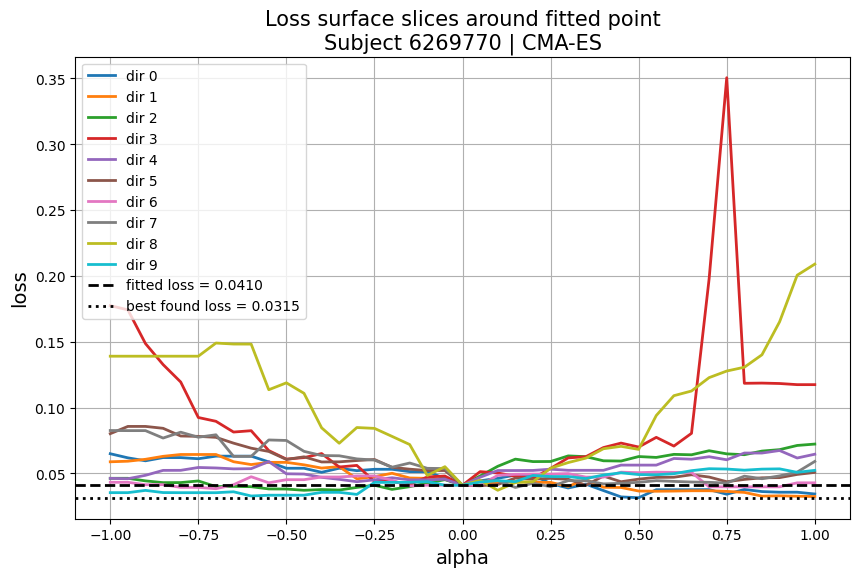

Saved zoomed figure to:
losses\6269770_CMA-ES_loss_zoomed.pdf


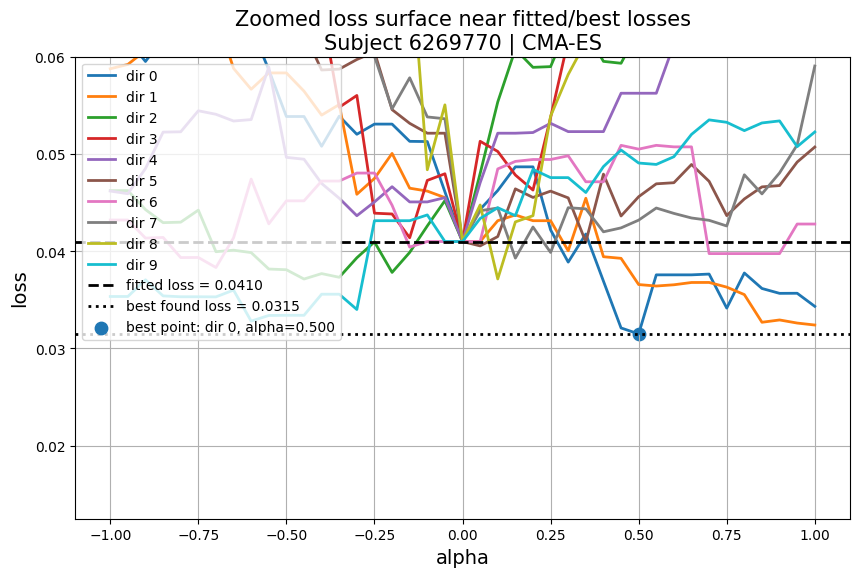


FINAL REPORT
Fitted loss: 0.041005
Fitted parameters:
  sigma_noise         : 0.104845
  A_repulsion         : 0.459508
  gamma               : 0.770726
  sigma_update        : 0.398532
  eta_learning        : 0.688318
  sigma_boundary      : 0.388483
  alpha               : 0.979646

Best found loss: 0.031493
Best found direction: 0
Best found alpha: 0.5000
Euclidean distance from fitted parameters: 0.499729
Best found parameters:
  sigma_noise         : 0.121024
  A_repulsion         : 0.500000
  gamma               : 0.805531
  sigma_update        : 0.302862
  eta_learning        : 0.783682
  sigma_boundary      : 0.862936
  alpha               : 0.922516


In [7]:
results = run_loss_surface(
    subject="6269770",
    opt_method="CMA-ES",
)

Loaded subject 6269770
N trials = 1200

lambda_A = 0.022115
lambda_B = 0.008210

FITTED POINT
Fitted loss = 0.027559
Fitted parameters:
  sigma_noise         : 0.099011
  A_repulsion         : 0.499931
  gamma               : 0.415736
  sigma_update        : 0.204130
  eta_learning        : 0.310139
  sigma_boundary      : 6.621977
  alpha               : 0.956196

BETTER SOLUTION FOUND
Direction: 4
Alpha: -0.8500
Loss: 0.027261
Params:
  sigma_noise         : 0.095121
  A_repulsion         : 0.495435
  gamma               : 0.328983
  sigma_update        : 0.235877
  eta_learning        : 0.325607
  sigma_boundary      : 5.777598
  alpha               : 0.929438

BETTER SOLUTION FOUND
Direction: 4
Alpha: -0.8000
Loss: 0.026308
Params:
  sigma_noise         : 0.095350
  A_repulsion         : 0.495700
  gamma               : 0.334087
  sigma_update        : 0.234010
  eta_learning        : 0.324697
  sigma_boundary      : 5.827267
  alpha               : 0.931012

BETTER SOLUTION FOUND


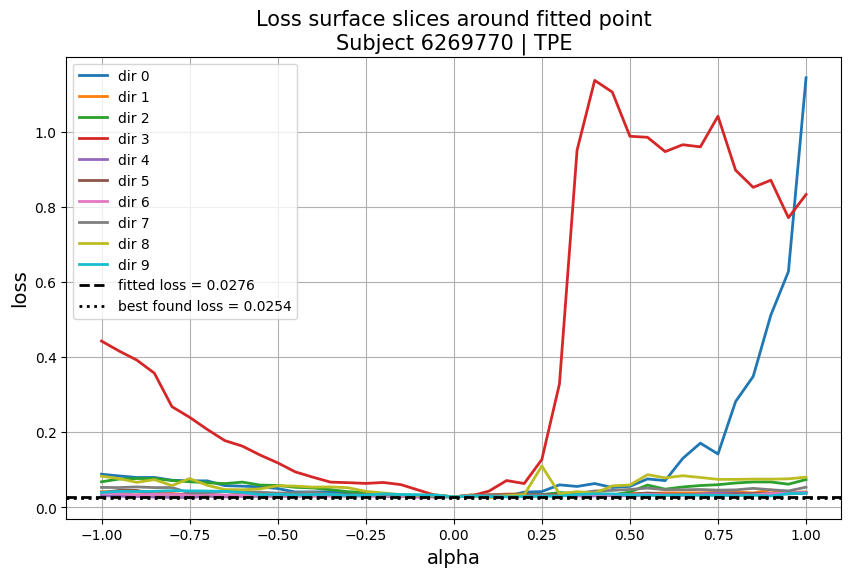

Saved zoomed figure to:
losses\6269770_TPE_loss_zoomed.pdf


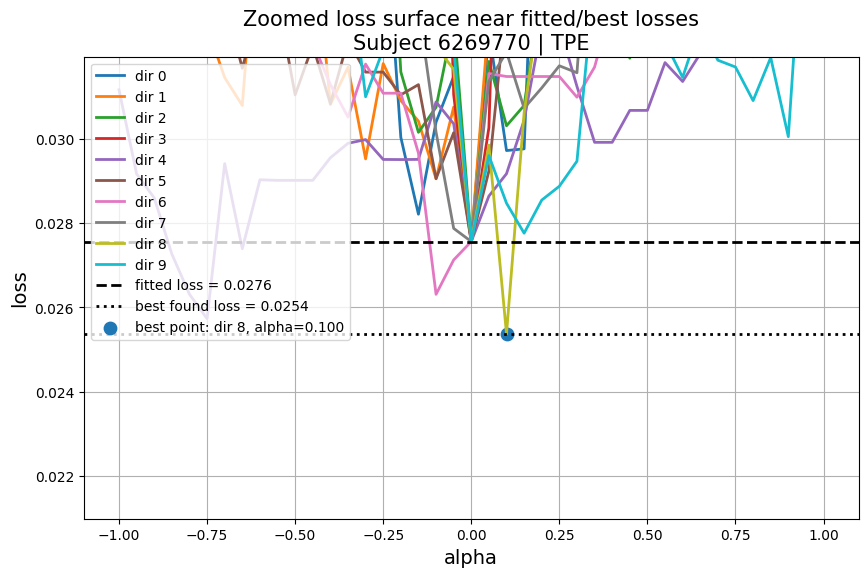


FINAL REPORT
Fitted loss: 0.027559
Fitted parameters:
  sigma_noise         : 0.099011
  A_repulsion         : 0.499931
  gamma               : 0.415736
  sigma_update        : 0.204130
  eta_learning        : 0.310139
  sigma_boundary      : 6.621977
  alpha               : 0.956196

Best found loss: 0.025368
Best found direction: 8
Best found alpha: 0.1000
Euclidean distance from fitted parameters: 0.100000
Best found parameters:
  sigma_noise         : 0.111652
  A_repulsion         : 0.499616
  gamma               : 0.376896
  sigma_update        : 0.197325
  eta_learning        : 0.311822
  sigma_boundary      : 6.707594
  alpha               : 0.925339


In [8]:
results = run_loss_surface(
    subject="6269770",
    opt_method="TPE",
)